## K-Means Clustering

`K-Means` is an **unsupervised learning algorithm** used for **clustering**.
It groups data points into **K clusters** such that points within a cluster are
similar to each other and dissimilar to points in other clusters.

K-Means is one of the most widely used clustering algorithms due to its
simplicity and efficiency.

---

### Why K-Means Is Needed

When labeled data is unavailable:
- We still want to discover patterns  
- Identify natural groupings  
- Understand data structure  

K-Means helps by:
- Grouping similar data points  
- Revealing hidden structure  
- Enabling segmentation and exploration  

---

### Core Idea of K-Means

K-Means works by:
- Assigning points to the nearest cluster center  
- Updating cluster centers to minimize within-cluster distance  

The objective is to minimize **within-cluster variance**.

---

### Objective Function

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$
J = \sum_{i=1}^{K} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

Where:
- \( K \) = number of clusters  
- \( C_i \) = set of points in cluster \( i \)  
- \( \mu_i \) = centroid of cluster \( i \)  

---

### How K-Means Works

1. Choose the number of clusters \( K \)  
2. Initialize \( K \) centroids randomly  
3. Assign each data point to the nearest centroid  
4. Update centroids as the mean of assigned points  
5. Repeat steps 3–4 until convergence  

---

### Distance Metric

- Uses **Euclidean distance** by default  
- Distance heavily influences clustering quality  

Because of this, **feature scaling is critical**.

---

### Convergence Behavior

K-Means converges when:
- Centroids stop changing  
- Assignments no longer change  
- Maximum iterations is reached  

The algorithm always converges, but not necessarily to a global optimum.

---

### Choosing the Value of K

#### Elbow Method
- Plot WCSS vs K  
- Look for the “elbow” point where improvement slows  

#### Silhouette Score
- Measures cluster separation and cohesion  
- Higher score indicates better clustering  

---

### Importance of Feature Scaling

- Features must be on the same scale  
- Unscaled features dominate distance calculation  
- Standardization or normalization is required  

---

### Advantages of K-Means

- Simple and easy to implement  
- Computationally efficient  
- Scales well to large datasets  
- Works well with spherical clusters  

---

### Limitations of K-Means

- Requires choosing K in advance  
- Sensitive to initialization  
- Sensitive to outliers  
- Assumes spherical clusters  
- Struggles with varying cluster sizes  

---

### K-Means vs Other Clustering Algorithms

| Aspect | K-Means | Hierarchical | DBSCAN |
|------|--------|--------------|--------|
| Requires K | Yes | No | No |
| Shape assumption | Spherical | Flexible | Arbitrary |
| Outlier handling | Poor | Moderate | Good |
| Scalability | High | Low | Moderate |

---

### When to Use K-Means

Use K-Means when:
- Clusters are compact and well-separated  
- Dataset is large  
- Speed is important  

Avoid when:
- Data contains many outliers  
- Clusters have complex shapes  
- Cluster sizes vary significantly  

---

### Practical Notes

- Use **K-Means++** for better initialization  
- Run multiple initializations (`n_init`)  
- Always scale features before clustering  

---

### Key Takeaways

- K-Means is a distance-based clustering algorithm  
- Minimizes within-cluster variance  
- Requires careful choice of K and feature scaling  
- Fast but sensitive to initialization and outliers  

K-Means is a foundational clustering algorithm and a starting point for
unsupervised learning and exploratory data analysis.


In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('../student_clustering.csv')
print("The shape of data is",df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


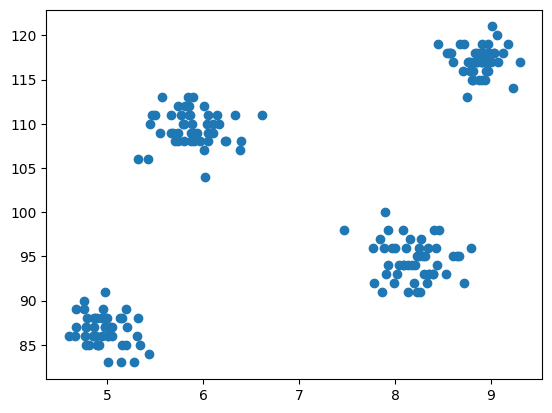

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'])

In [6]:
from sklearn.cluster import KMeans

In [7]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)


In [8]:
wcss

[29957.898288,
 4184.14127,
 2362.713349,
 2423.141985576697,
 523.7131894763966,
 388.85240268759816,
 312.1712145985568,
 284.5750810651043,
 206.72239593998566,
 197.07868361796014]

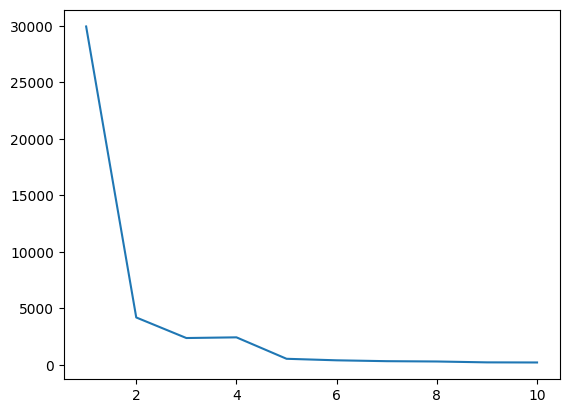

In [9]:
plt.plot(range(1,11),wcss)

In [10]:
X = df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)
y_means

array([1, 2, 3, 3, 2, 2, 3, 0, 2, 3, 1, 2, 3, 1, 2, 3, 2, 3, 2, 2, 3, 1,
       3, 1, 1, 3, 1, 0, 3, 2, 0, 2, 0, 2, 3, 3, 0, 2, 1, 2, 1, 3, 3, 1,
       0, 0, 3, 2, 0, 2, 1, 1, 0, 3, 0, 2, 2, 0, 2, 0, 2, 3, 3, 0, 1, 0,
       3, 1, 2, 3, 2, 0, 3, 1, 2, 0, 2, 0, 1, 3, 3, 0, 2, 1, 0, 1, 0, 2,
       0, 2, 0, 0, 3, 1, 3, 3, 0, 3, 1, 0, 2, 1, 1, 0, 1, 1, 3, 1, 0, 0,
       3, 0, 2, 2, 3, 0, 3, 2, 0, 1, 1, 2, 3, 0, 3, 1, 3, 2, 1, 3, 3, 2,
       1, 1, 2, 0, 2, 1, 3, 3, 3, 1, 2, 1, 1, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       1, 3, 2, 0, 2, 3, 1, 0, 2, 3, 0, 1, 2, 1, 1, 0, 0, 2, 0, 1, 1, 3,
       0, 2, 1, 0, 0, 2, 2, 2, 3, 1, 3, 3, 0, 2, 3, 3, 1, 1, 3, 1, 0, 2,
       2, 0], dtype=int32)

In [11]:
X[y_means == 3,1]

array([ 93.,  97.,  98.,  94.,  97.,  95.,  91.,  98.,  92.,  98.,  94.,
        96.,  96.,  96.,  93.,  94.,  96.,  96.,  95.,  93.,  95.,  94.,
        92.,  91.,  92.,  95.,  94.,  95.,  92.,  94.,  91.,  95.,  93.,
        97.,  98.,  96.,  93., 100.,  96.,  94.,  95.,  93.,  92.,  98.,
        96.,  93.,  91.,  93.,  94.,  96.])

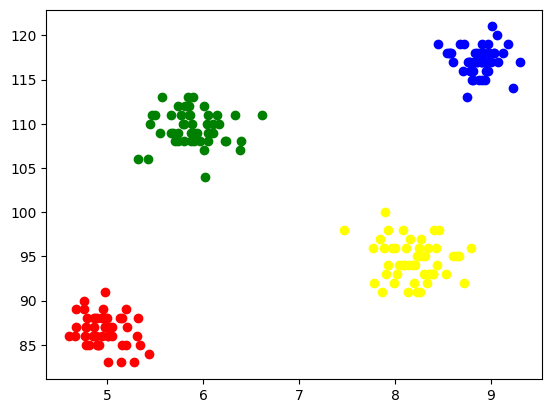

In [12]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='blue')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='red')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')

### K-Means on 3-D Data

In [13]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

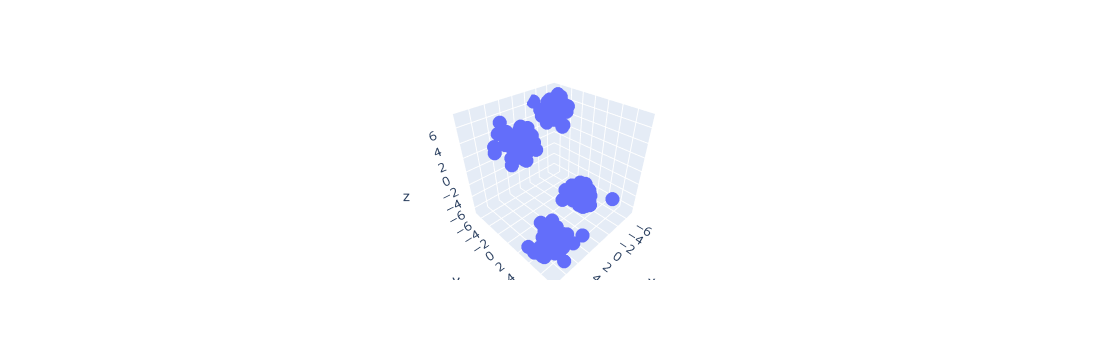

In [14]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [15]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

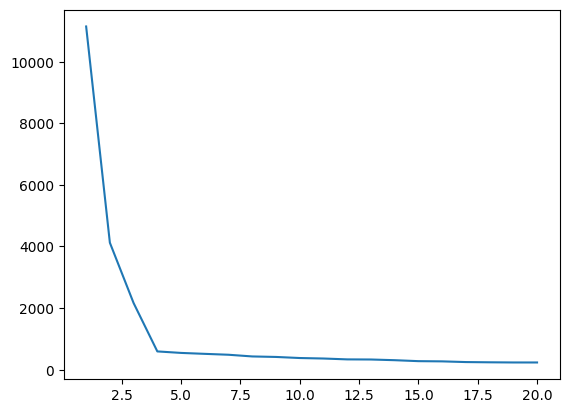

In [16]:
plt.plot(range(1,21),wcss)

In [17]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [18]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

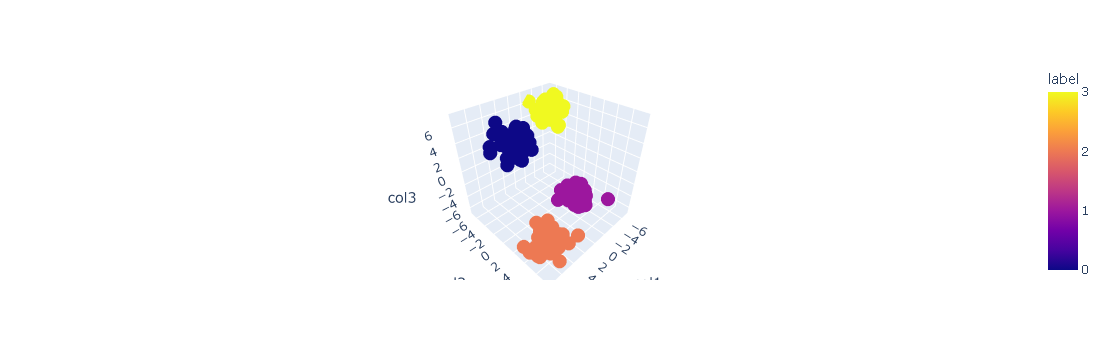

In [19]:
fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()